# Climate Extreme Risk Atlas

This mature case mirrors Pangeo-style climate notebooks with an offline city climate cube. It moves from climate data QA to extreme indices, trend diagnostics, EOF decomposition, and population-weighted risk ranking.

In [1]:
from pathlib import Path
import os, warnings
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
PROJECT = Path.cwd()
DATA = PROJECT / "data"
OUTPUTS = PROJECT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
print(f"Project: {PROJECT}")
print(f"Data files: {[p.name for p in sorted(DATA.iterdir())]}")

Project: /workspace
Data files: ['city_climate_daily.nc']


In [2]:
ds = xr.open_dataset(DATA / "city_climate_daily.nc")
summary = pd.DataFrame({
    "variable": list(ds.data_vars),
    "dims": [str(ds[v].dims) for v in ds.data_vars],
    "min": [float(ds[v].min()) for v in ds.data_vars],
    "max": [float(ds[v].max()) for v in ds.data_vars],
})
display(ds)
display(summary.round(2))

<xarray.Dataset> Size: 3MB
Dimensions:         (time: 1826, lat: 12, lon: 16)
Coordinates:
  * time            (time) datetime64[ns] 15kB 2018-01-01 ... 2022-12-31
  * lat             (lat) float64 96B 31.1 31.2 31.31 ... 32.04 32.15 32.25
  * lon             (lon) float64 128B 118.3 118.4 118.5 ... 119.6 119.8 119.8
Data variables:
    tasmax          (time, lat, lon) float32 1MB 12.68 11.57 ... 17.17 11.96
    precip          (time, lat, lon) float32 1MB 0.6882 2.625 ... 9.741 7.388
    urban_fraction  (lat, lon) float32 768B 0.0929 0.05275 ... 0.1128 0.02904
    elevation       (lat, lon) float32 768B 47.46 61.62 48.07 ... 60.61 54.59
    population      (lat, lon) float32 768B 1.976e+03 2.395e+03 ... 1.632e+03
Attributes:
    description:  Synthetic but realistic city climate panel for offline extr...

,variable,dims,min,max
0,tasmax,"('time', 'lat', 'lon')",2.78,47.90
1,precip,"('time', 'lat', 'lon')",0.00,111.02
2,urban_fraction,"('lat', 'lon')",0.01,1.00
3,elevation,"('lat', 'lon')",45.28,196.43
4,population,"('lat', 'lon')",993.53,9286.95


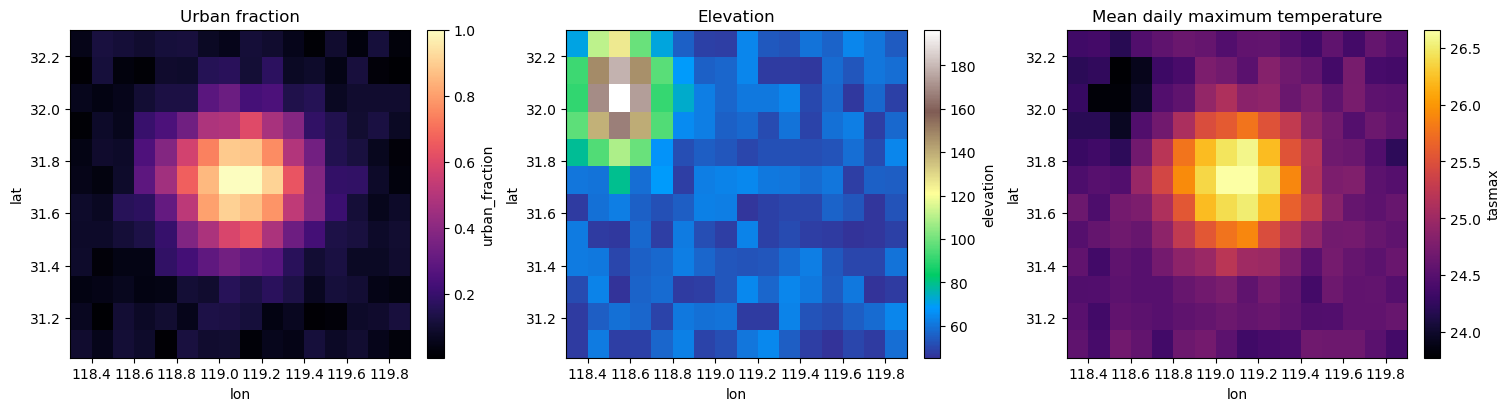

Saved outputs/climate_domain_overview.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
ds["urban_fraction"].plot(ax=axes[0], cmap="magma", add_colorbar=True)
axes[0].set_title("Urban fraction")
ds["elevation"].plot(ax=axes[1], cmap="terrain", add_colorbar=True)
axes[1].set_title("Elevation")
ds["tasmax"].mean("time").plot(ax=axes[2], cmap="inferno", add_colorbar=True)
axes[2].set_title("Mean daily maximum temperature")
fig.savefig(OUTPUTS / "climate_domain_overview.png", dpi=160)
plt.show()
print("Saved outputs/climate_domain_overview.png")

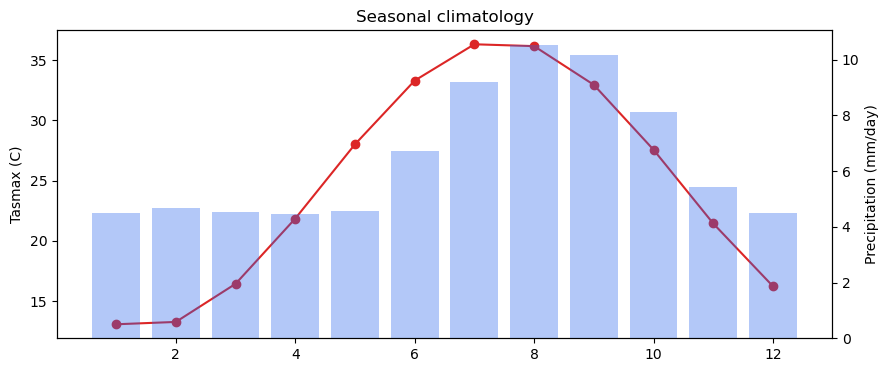

,month,tasmax_c,precip_mm_day
0,1,13.090000,4.48
1,2,13.280000,4.67
2,3,16.440001,4.52
3,4,21.860001,4.46
4,5,28.020000,4.56
5,6,33.299999,6.71
6,7,36.320000,9.18
7,8,36.160000,10.53
8,9,32.950001,10.17
9,10,27.570000,8.12


In [4]:
monthly = ds[["tasmax", "precip"]].groupby("time.month").mean()
clim_table = pd.DataFrame({
    "month": monthly.month.values,
    "tasmax_c": monthly["tasmax"].mean(["lat", "lon"]).values,
    "precip_mm_day": monthly["precip"].mean(["lat", "lon"]).values,
})
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(clim_table["month"], clim_table["tasmax_c"], color="#dc2626", marker="o", label="Tasmax")
ax1.set_ylabel("Tasmax (C)")
ax2 = ax1.twinx()
ax2.bar(clim_table["month"], clim_table["precip_mm_day"], alpha=0.35, color="#2563eb", label="Precip")
ax2.set_ylabel("Precipitation (mm/day)")
ax1.set_title("Seasonal climatology")
fig.savefig(OUTPUTS / "seasonal_climatology.png", dpi=160)
plt.show()
display(clim_table.round(2))

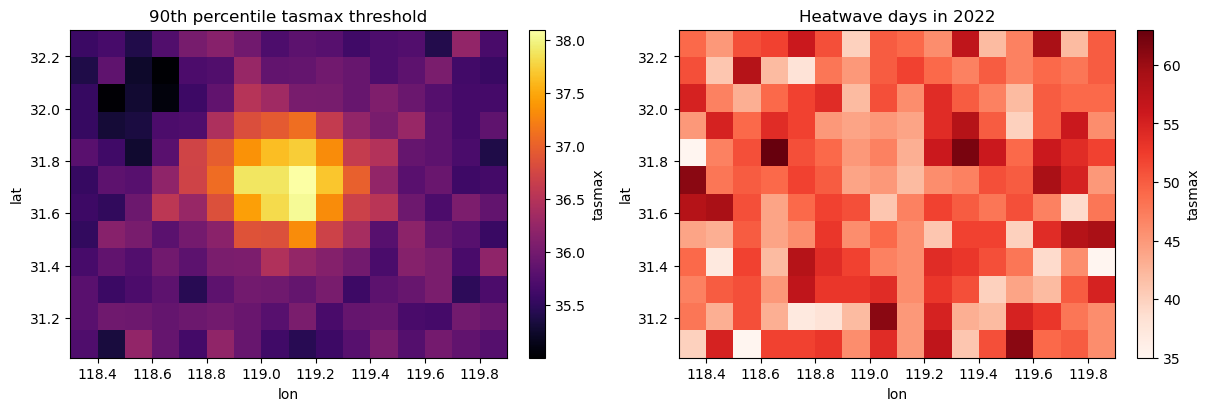

,quantile,city_mean_heatwave_days
year,,
2018,0.9,32.12
2019,0.9,36.86
2020,0.9,41.01
2021,0.9,44.34
2022,0.9,48.87


In [5]:
baseline = ds.sel(time=slice("2018-01-01", "2020-12-31"))
heat_threshold = baseline["tasmax"].quantile(0.9, dim="time")
heatwave = ds["tasmax"] > heat_threshold
annual_heat = heatwave.groupby("time.year").sum("time")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
heat_threshold.plot(ax=axes[0], cmap="inferno")
axes[0].set_title("90th percentile tasmax threshold")
annual_heat.sel(year=2022).plot(ax=axes[1], cmap="Reds")
axes[1].set_title("Heatwave days in 2022")
fig.savefig(OUTPUTS / "heatwave_threshold_and_days.png", dpi=160)
plt.show()
display(annual_heat.mean(["lat", "lon"]).to_dataframe(name="city_mean_heatwave_days").round(2))

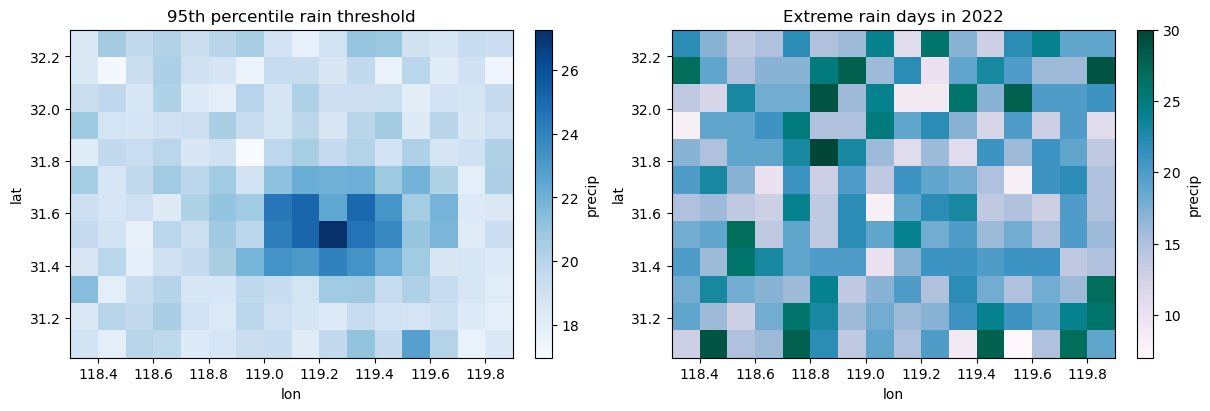

,quantile,city_mean_extreme_rain_days
year,,
2018,0.95,18.33
2019,0.95,17.97
2020,0.95,18.70
2021,0.95,18.48
2022,0.95,18.48


In [6]:
rain_threshold = baseline["precip"].quantile(0.95, dim="time")
extreme_rain = ds["precip"] > rain_threshold
annual_rain = extreme_rain.groupby("time.year").sum("time")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
rain_threshold.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("95th percentile rain threshold")
annual_rain.sel(year=2022).plot(ax=axes[1], cmap="PuBuGn")
axes[1].set_title("Extreme rain days in 2022")
fig.savefig(OUTPUTS / "rain_extremes.png", dpi=160)
plt.show()
display(annual_rain.mean(["lat", "lon"]).to_dataframe(name="city_mean_extreme_rain_days").round(2))

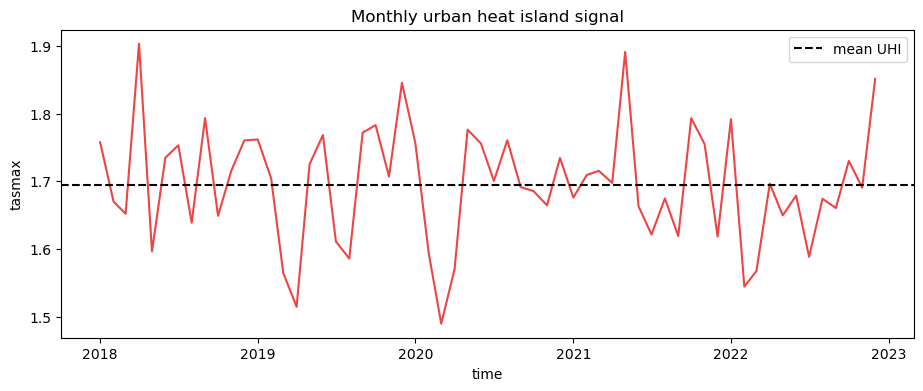

Mean monthly UHI: 1.70 C


In [7]:
urban_mask = ds["urban_fraction"] >= 0.55
rural_mask = ds["urban_fraction"] <= 0.25
urban_ts = ds["tasmax"].where(urban_mask).mean(["lat", "lon"])
rural_ts = ds["tasmax"].where(rural_mask).mean(["lat", "lon"])
uhi = (urban_ts - rural_ts).resample(time="MS").mean()
fig, ax = plt.subplots(figsize=(11, 4))
uhi.plot(ax=ax, color="#ef4444")
ax.axhline(float(uhi.mean()), color="black", linestyle="--", label="mean UHI")
ax.set_title("Monthly urban heat island signal")
ax.legend()
fig.savefig(OUTPUTS / "urban_heat_island_timeseries.png", dpi=160)
plt.show()
print(f"Mean monthly UHI: {float(uhi.mean()):.2f} C")

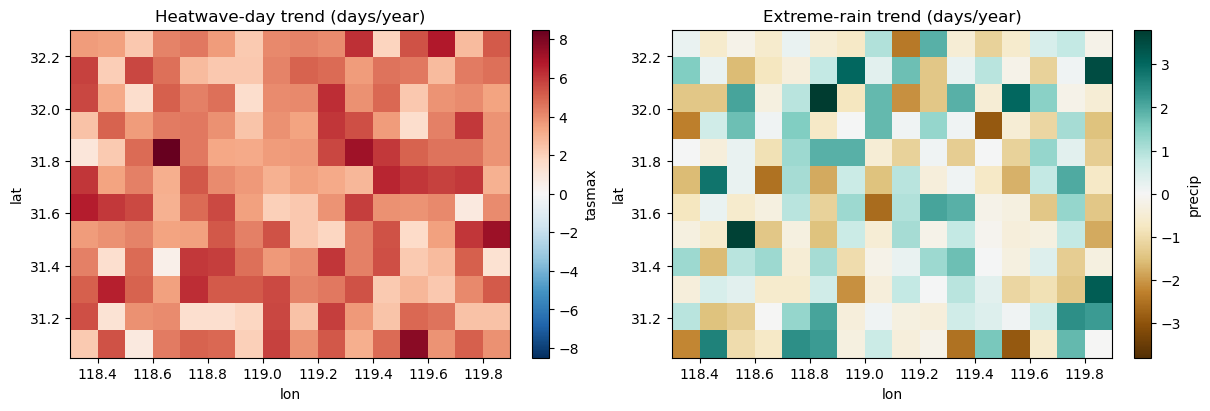

Median heatwave trend: 4.10 days/year


In [8]:
years = annual_heat.year.values.astype(float)
def slope_per_year(values):
    return np.polyfit(years, values, 1)[0]
heat_slope = xr.apply_ufunc(
    slope_per_year,
    annual_heat,
    input_core_dims=[["year"]],
    vectorize=True,
    output_dtypes=[float],
)
rain_slope = xr.apply_ufunc(
    slope_per_year,
    annual_rain,
    input_core_dims=[["year"]],
    vectorize=True,
    output_dtypes=[float],
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
heat_slope.plot(ax=axes[0], cmap="RdBu_r", center=0)
axes[0].set_title("Heatwave-day trend (days/year)")
rain_slope.plot(ax=axes[1], cmap="BrBG", center=0)
axes[1].set_title("Extreme-rain trend (days/year)")
fig.savefig(OUTPUTS / "extreme_trend_maps.png", dpi=160)
plt.show()
print(f"Median heatwave trend: {float(heat_slope.median()):.2f} days/year")

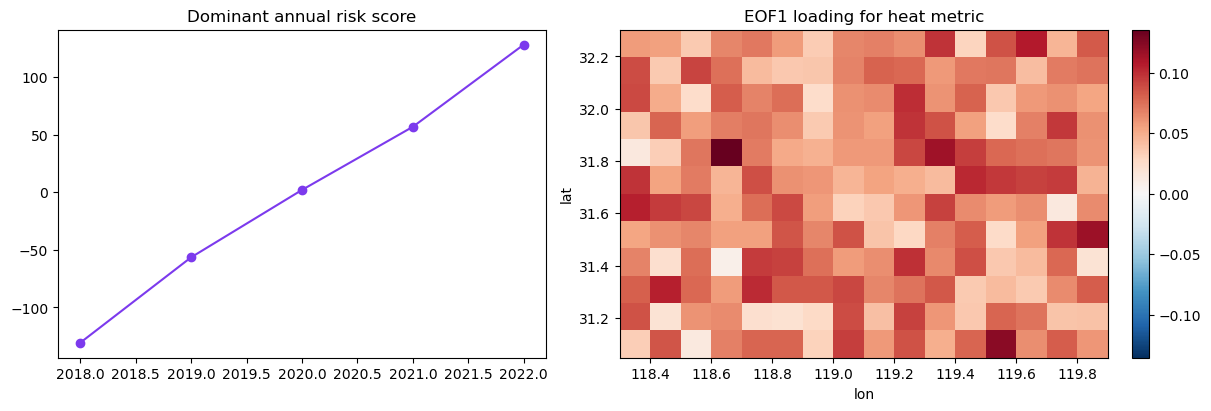

EOF1 explained variance: 64.58%


In [9]:
annual_stack = xr.concat([
    annual_heat.rename("heatwave_days"),
    annual_rain.rename("extreme_rain_days")
], dim=pd.Index(["heat", "rain"], name="metric")).transpose("year", "metric", "lat", "lon")
matrix = annual_stack.values.reshape(len(years), -1)
matrix = matrix - matrix.mean(axis=0)
u, s, vt = np.linalg.svd(matrix, full_matrices=False)
pc1 = pd.Series(u[:, 0] * s[0], index=annual_heat.year.values, name="PC1")
eof1 = xr.DataArray(vt[0].reshape(2, len(ds.lat), len(ds.lon))[0], coords={"lat": ds.lat, "lon": ds.lon}, dims=("lat", "lon"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
pc1.plot(ax=axes[0], marker="o", color="#7c3aed")
axes[0].set_title("Dominant annual risk score")
eof1.plot(ax=axes[1], cmap="RdBu_r", center=0)
axes[1].set_title("EOF1 loading for heat metric")
fig.savefig(OUTPUTS / "climate_eof_diagnostics.png", dpi=160)
plt.show()
print(f"EOF1 explained variance: {(s[0] ** 2 / (s ** 2).sum()):.2%}")

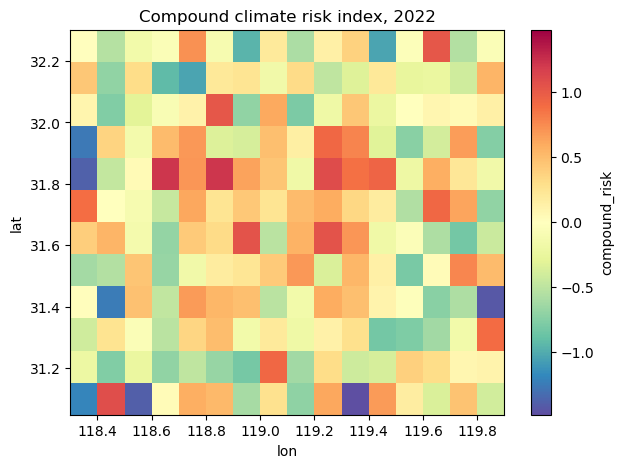

,lat,lon,year,compound_risk,population,heatwave_days,extreme_rain_days
115,31.832,118.65,2022,1.222,3341.685059,63,19
117,31.832,118.85,2022,1.221,6312.500000,49,30
121,31.832,119.25,2022,1.090,7704.371094,56,16
1,31.100,118.45,2022,1.083,2395.431885,55,29
89,31.623,119.25,2022,1.052,7011.722168,52,22
86,31.623,118.95,2022,1.048,7542.800781,51,22
149,32.041,118.85,2022,1.029,2579.398926,54,29
189,32.250,119.65,2022,1.026,1976.948975,59,24
123,31.832,119.45,2022,0.945,4440.782227,56,21
109,31.727,119.65,2022,0.923,2593.540039,59,21


In [10]:
heat_2022 = annual_heat.sel(year=2022)
rain_2022 = annual_rain.sel(year=2022)
z_heat = (heat_2022 - heat_2022.mean()) / heat_2022.std()
z_rain = (rain_2022 - rain_2022.mean()) / rain_2022.std()
z_pop = (ds["population"] - ds["population"].mean()) / ds["population"].std()
risk = (0.45 * z_heat + 0.30 * z_rain + 0.25 * z_pop).rename("compound_risk")
risk_table = risk.to_dataframe().reset_index()
risk_table["population"] = ds["population"].values.ravel()
risk_table["heatwave_days"] = heat_2022.values.ravel()
risk_table["extreme_rain_days"] = rain_2022.values.ravel()
risk_table = risk_table.sort_values("compound_risk", ascending=False).head(12)
fig, ax = plt.subplots(figsize=(7, 5))
risk.plot(ax=ax, cmap="Spectral_r")
ax.set_title("Compound climate risk index, 2022")
fig.savefig(OUTPUTS / "compound_climate_risk.png", dpi=160)
plt.show()
display(risk_table.round(3))

In [11]:
exports = {
    "annual_heatwave_days.csv": annual_heat.mean(["lat", "lon"]).to_dataframe(name="city_mean_heatwave_days"),
    "annual_extreme_rain_days.csv": annual_rain.mean(["lat", "lon"]).to_dataframe(name="city_mean_extreme_rain_days"),
    "compound_risk_top_cells.csv": risk_table,
}
for name, frame in exports.items():
    frame.to_csv(OUTPUTS / name)
print("Exported files:")
for path in sorted(OUTPUTS.iterdir()):
    print(f"- {path.name} ({path.stat().st_size} bytes)")

Exported files:
- annual_extreme_rain_days.csv (159 bytes)
- annual_heatwave_days.csv (166 bytes)
- climate_domain_overview.png (68416 bytes)
- climate_eof_diagnostics.png (58207 bytes)
- compound_climate_risk.png (35763 bytes)
- compound_risk_top_cells.csv (939 bytes)
- extreme_trend_maps.png (49233 bytes)
- heatwave_threshold_and_days.png (51585 bytes)
- rain_extremes.png (45230 bytes)
- seasonal_climatology.png (54029 bytes)
- urban_heat_island_timeseries.png (78263 bytes)


In [12]:
display(Markdown(f'''## Case conclusion

The city climate cube shows a mean monthly urban heat island of **{float(uhi.mean()):.2f} C**. The highest compound-risk cells combine dense population, high 2022 heatwave frequency, and elevated extreme-rain exposure. These cells are exported in `compound_risk_top_cells.csv` for follow-up adaptation planning.
'''))

## Case conclusion

The city climate cube shows a mean monthly urban heat island of **1.70 C**. The highest compound-risk cells combine dense population, high 2022 heatwave frequency, and elevated extreme-rain exposure. These cells are exported in `compound_risk_top_cells.csv` for follow-up adaptation planning.
